# Dataset SOYBEAN

## Imports

In [23]:
#!pip install scipy
import os
import sys
from scipy.io import arff
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report
import itertools


# Add the parent directory to sys.path to be able to import own packages from outside the notebooks directory
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# some helper functions (see src directory for details)
from src.utils import *
from src.evaluation import *

## Data Inspection and Split

In [24]:
# Load the data and catch a quick glimpse.
curr_dir = os.getcwd()
data_path = os.path.join(curr_dir, '..', 'data', 'soybean/dataset_soybean.arff')

with open(data_path, 'r') as f:
    arff_data, meta = arff.loadarff(f)
cols = meta.names()
df_soybean = pd.DataFrame(arff_data, columns=cols)
df_soybean = df_soybean.select_dtypes([object])
df_soybean = df_soybean.stack().str.decode('utf-8').unstack()

df_soybean.describe()

,date,plant-stand,precip,temp,hail,crop-hist,area-damaged,severity,seed-tmt,germination,...,sclerotia,fruit-pods,fruit-spots,seed,mold-growth,seed-discolor,seed-size,shriveling,roots,class
count,683,683,683,683,683,683,683,683,683,683,...,683,683,683,683,683,683,683,683,683,683
unique,8,3,4,4,3,5,5,4,4,4,...,3,5,5,3,3,3,3,3,4,19
top,september,normal,gt-norm,norm,yes,same-lst-two-yrs,low-areas,pot-severe,none,80-89,...,absent,norm,absent,norm,absent,absent,norm,absent,norm,brown-spot
freq,149,354,459,374,435,219,227,322,305,213,...,625,407,345,476,524,513,532,539,551,92


C:\Users\PC\AppData\Local\Temp\ipykernel_14888\3293990450.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_soybean['class'], order=df_soybean['class'].value_counts().index, palette='viridis')


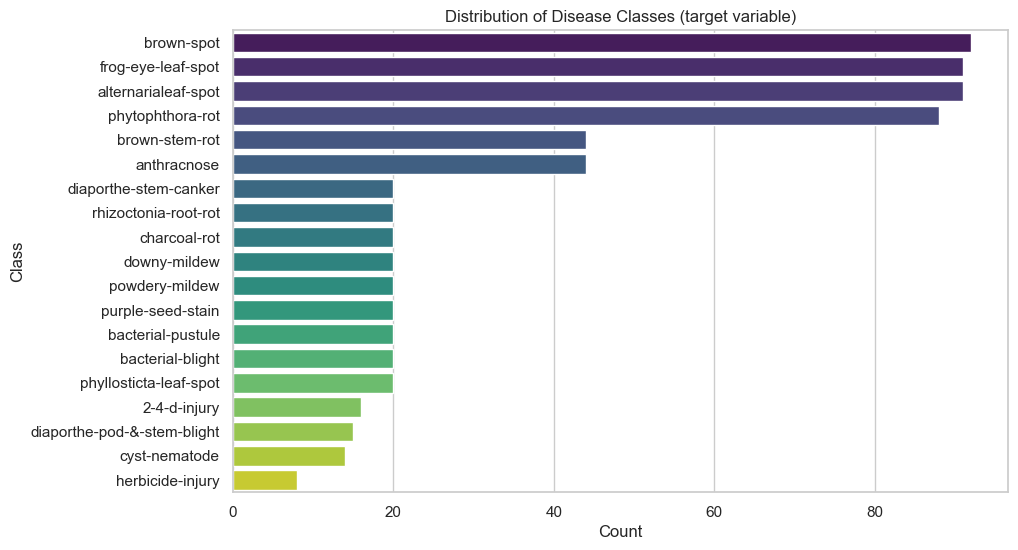

In [25]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10,6))
sns.countplot(y=df_soybean['class'], order=df_soybean['class'].value_counts().index, palette='viridis')
plt.title('Distribution of Disease Classes (target variable)')
plt.xlabel('Count')
plt.ylabel('Class')
plt.show()

Because of the lack of samples for the last 4 classes, we will remove them from the dataset as was done in previous work. We remove these because it is hard to predict and capture the characteristics of these classes, with such a small sample.

In [26]:

df_soybean_reduced = df_soybean[~df_soybean['class'].isin(['herbicide-injury', 'cyst-nematode', 'diaporthe-pod-&-stem-blight', '2-4-d-injury'])].reset_index(drop=True)

In [27]:
X = df_soybean_reduced.drop(columns=['class'])
y = df_soybean_reduced['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=123)

categorical_features = X.columns

### Missing Values

In [28]:
sum(df_soybean_reduced.isnull().sum())

0

At first seems like there are no missing values, however when we look at the dataset description, we see that missing values are denoted as "?" so we cant check for them like this

In [29]:
def missing_values_table(df):
    results = []

    for column in df.columns:
        count = (df[column] == '?').sum()
        percent = (count / len(df)) * 100
        results.append({
            'Column': column,
            'Missing_Count': count,
            'Missing_Percent': percent
        })

    results_df = pd.DataFrame(results)
    results_df = results_df[results_df['Missing_Count'] > 0].sort_values('Missing_Percent', ascending=False)

    print("Missing Values Analysis (sorted by %):")
    print("=" * 40)

    if len(results_df) > 0:
        for _, row in results_df.iterrows():
            print(f"{row['Column']}: {row['Missing_Count']} missing ({row['Missing_Percent']:.1f}%)")
    else:
        print("No '?' values found in any column!")
missing_values_table(df_soybean_reduced)

Missing Values Analysis (sorted by %):
hail: 68 missing (10.8%)
severity: 68 missing (10.8%)
seed-tmt: 68 missing (10.8%)
germination: 68 missing (10.8%)
lodging: 68 missing (10.8%)
seed-discolor: 68 missing (10.8%)
mold-growth: 68 missing (10.8%)
seed: 68 missing (10.8%)
fruit-spots: 68 missing (10.8%)
fruit-pods: 68 missing (10.8%)
fruiting-bodies: 68 missing (10.8%)
seed-size: 68 missing (10.8%)
shriveling: 68 missing (10.8%)
leaf-mild: 55 missing (8.7%)
leaf-malf: 55 missing (8.7%)
leafspots-halo: 55 missing (8.7%)
leafspots-marg: 55 missing (8.7%)
leaf-shread: 55 missing (8.7%)
leafspot-size: 55 missing (8.7%)


A lot of the columns have missing values (32 / 36), but its not that bad since they dont even exceed 25% for any of the columns (~12% overall)

METHODS TO TRY:
- mode imputation (repalcing with most frequent) - (using `SimpleImputer` with indicator?)
- keep "?" as a missing category (maybe missing contains information)
- KNN-imputation (replacing based on neighbors) - maybe too difficult?

Since the `SimpleImputer` adds columns that capture the information whether a column was missing or not, the second option is not that necessary, so we will continue with mode imputation with and without indicator.




### Encoding

We can try:
- One Hot encoding-creates binary columns for each unique value -> explodes count of attributes (good for numeric methods such as KNN and SVM)
- Ordinal encoding-converts nominal to integer codes (good for tree-based methods)


In [ ]:
# This shows the class distribution -> imbalanced!
y.value_counts(normalize=True)

class
brown-spot                0.146032
frog-eye-leaf-spot        0.144444
alternarialeaf-spot       0.144444
phytophthora-rot          0.139683
anthracnose               0.069841
brown-stem-rot            0.069841
diaporthe-stem-canker     0.031746
downy-mildew              0.031746
powdery-mildew            0.031746
charcoal-rot              0.031746
rhizoctonia-root-rot      0.031746
purple-seed-stain         0.031746
bacterial-pustule         0.031746
bacterial-blight          0.031746
phyllosticta-leaf-spot    0.031746
Name: proportion, dtype: float64

## Model training

In [31]:
# --- Imputers ---
imputers = {
    'mode_indicator': SimpleImputer(strategy='most_frequent', add_indicator=True, missing_values='?'),
    'none': 'passthrough',
}

# --- Encoders ---
encoders = {
    'onehot': OneHotEncoder(handle_unknown='ignore', sparse_output=False),
    'ordinal': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
}

# --- Scalers ---
scalers = {
    'none': 'passthrough',
    'standard': StandardScaler(with_mean=False)
}


In [32]:
models = {
    'DecisionTree': (
        DecisionTreeClassifier(random_state=42),
        {'clf__max_depth': [None, 5, 10], 'clf__criterion': ['gini', 'entropy'], 'clf__class_weight': [None, 'balanced']}
    ),
    'KNN': (
        KNeighborsClassifier(),
        {'clf__n_neighbors': [3, 5, 7], 'clf__weights': ['uniform', 'distance']}
    ),
    'SVM': (
        SVC(random_state=42),
        {'clf__C': [0.1, 1, 10], 'clf__kernel': ['linear', 'rbf'], 'clf__class_weight': [None, 'balanced']}
    )
}


In [33]:
from sklearn.model_selection import GridSearchCV

results = []

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

for imp_name, imputer in imputers.items():
    for enc_name, encoder in encoders.items():
        for sc_name, scaler in scalers.items():
            for model_name, (clf, param_grid) in models.items():
                
                # Preprocessing pipeline

                preprocessor = ColumnTransformer([
                    ('cat', Pipeline([
                        ('imputer', imputer),
                        ('encoder', encoder),
                        ('scaler', scaler)
                    ]), categorical_features)
                ])

                pipe = Pipeline([
                    ('preprocess', preprocessor),
                    ('clf', clf)
                ])

                # Grid search for hyperparameter tuning
                grid = GridSearchCV(
                    estimator=pipe,
                    param_grid=param_grid,
                    scoring='f1_macro',
                    cv=cv,
                    n_jobs=-1
                )



                print(f"\n=== BEST {imp_name} + {enc_name} + {sc_name} + {model_name} ===")
                
                metrics = []
                grid.fit(X_train, y_train)
                best_model = grid.best_estimator_
                y_pred_best = best_model.predict(X_test)

                eval_dict_best = evaluate_run(
                    name=f"BEST {imp_name}_{enc_name}_{sc_name}_{model_name}",
                    y_true=y_test,
                    y_pred=y_pred_best,
                    task_type="classification"
                )
                metrics.append(eval_dict_best)
                df_metrics1 = pd.DataFrame(metrics)
                agg = df_metrics1[['accuracy', 'balanced_accuracy', 'f1', 'precision', 'recall']].agg(['mean', 'std'])
                results.append({
                    "Preprocessing": imp_name + "_" + enc_name + "_" + sc_name,
                    "Classifier": "Best" + model_name,
                    "accuracy_mean": agg.loc['mean', 'accuracy'],
                    "accuracy_std": agg.loc['std', 'accuracy'],
                    "b_accuracy_mean": agg.loc['mean', 'balanced_accuracy'],
                    "b_accuracy_std": agg.loc['std', 'balanced_accuracy'],
                    "f1_mean": agg.loc['mean', 'f1'],
                    "f1_std": agg.loc['std', 'f1'],
                    "precision_mean": agg.loc['mean', 'precision'],
                    "recall_mean": agg.loc['mean', 'recall']
                })



                print(f"\n=== {imp_name} + {enc_name} + {sc_name} + {model_name} ===")
                fold_metrics = []
                for fold, (train_idx, test_idx) in enumerate(cv.split(X_train, y_train)):
                    X_train_fold, X_test_fold = X_train.iloc[train_idx], X_train.iloc[test_idx]
                    y_train_fold, y_test_fold = y_train.iloc[train_idx], y_train.iloc[test_idx]

                    pipe.fit(X_train_fold, y_train_fold)
                    y_pred = pipe.predict(X_test_fold) 

                    eval_dict = evaluate_run(
                        name=f"{imp_name}_{enc_name}_{sc_name}_{model_name}",
                        y_true=y_test_fold,
                        y_pred=y_pred,
                        task_type="classification"
                    )
                    fold_metrics.append(eval_dict)
                                
                df_metrics = pd.DataFrame(fold_metrics)
                agg = df_metrics[['accuracy', 'balanced_accuracy', 'f1', 'precision', 'recall']].agg(['mean', 'std'])
                results.append({
                    "Preprocessing": imp_name + "_" + enc_name + "_" + sc_name,
                    "Classifier": model_name,
                    "accuracy_mean": agg.loc['mean', 'accuracy'],
                    "accuracy_std": agg.loc['std', 'accuracy'],
                    "b_accuracy_mean": agg.loc['mean', 'balanced_accuracy'],
                    "b_accuracy_std": agg.loc['std', 'balanced_accuracy'],
                    "f1_mean": agg.loc['mean', 'f1'],
                    "f1_std": agg.loc['std', 'f1'],
                    "precision_mean": agg.loc['mean', 'precision'],
                    "recall_mean": agg.loc['mean', 'recall']
                })


# Convert to DataFrame for easy analysis
results_df = pd.DataFrame(results).sort_values(by='f1_mean', ascending=False)



=== BEST mode_indicator + onehot + none + DecisionTree ===



=== mode_indicator + onehot + none + DecisionTree ===


c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod


=== BEST mode_indicator + onehot + none + KNN ===

=== mode_indicator + onehot + none + KNN ===


c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

...

c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



=== BEST none + ordinal + standard + KNN ===

=== none + ordinal + standard + KNN ===


c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod


=== BEST none + ordinal + standard + SVM ===

=== none + ordinal + standard + SVM ===


c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

## Model Evaluation

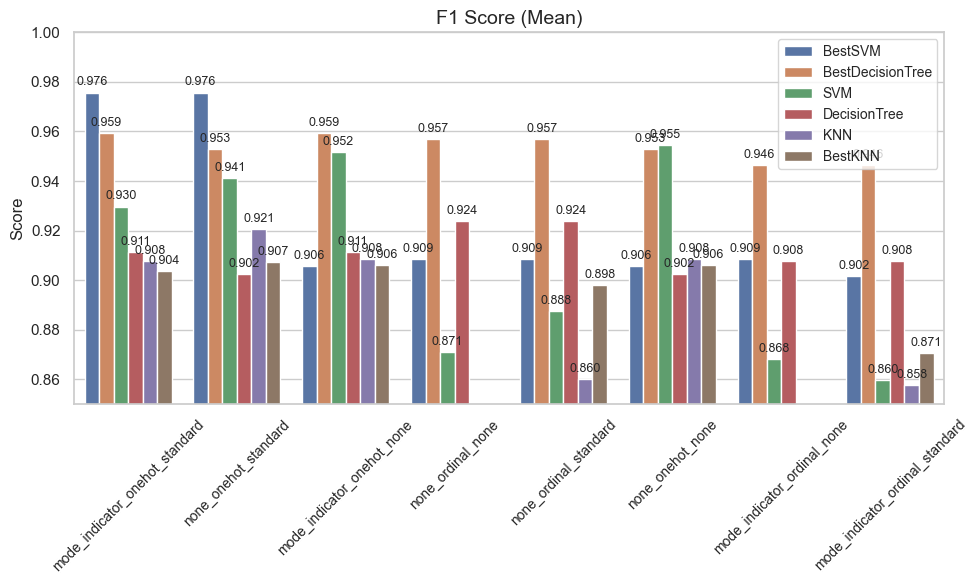


Cross-validation summary:


,Preprocessing,Classifier,accuracy_mean,accuracy_std,b_accuracy_mean,b_accuracy_std,f1_mean,f1_std,precision_mean,recall_mean
10,mode_indicator_onehot_standard,BestSVM,0.960317,NaN,0.981481,NaN,0.975688,NaN,0.974545,0.981481
34,none_onehot_standard,BestSVM,0.960317,NaN,0.981481,NaN,0.975688,NaN,0.974545,0.981481
6,mode_indicator_onehot_standard,BestDecisionTree,0.952381,NaN,0.951852,NaN,0.959454,NaN,0.978519,0.951852
0,mode_indicator_onehot_none,BestDecisionTree,0.952381,NaN,0.951852,NaN,0.959454,NaN,0.978519,0.951852
36,none_ordinal_none,BestDecisionTree,0.936508,NaN,0.970370,NaN,0.956975,NaN,0.953095,0.970370
42,none_ordinal_standard,BestDecisionTree,0.936508,NaN,0.970370,NaN,0.956975,NaN,0.953095,0.970370
29,none_onehot_none,SVM,0.930627,0.024777,0.955595,0.031125,0.954515,0.032597,0.961276,0.955595
30,none_onehot_standard,BestDecisionTree,0.928571,NaN,0.966667,NaN,0.952816,NaN,0.948373,0.966667
24,none_onehot_none,BestDecisionTree,0.928571,NaN,0.966667,NaN,0.952816,NaN,0.948373,0.966667
5,mode_indicator_onehot_none,SVM,0.928667,0.022824,0.952381,0.029928,0.951730,0.031202,0.960708,0.952381


In [34]:
metrics = ["accuracy_mean", "b_accuracy_mean", "f1_mean", "precision_mean", "recall_mean"]

# Adapted method from Nico's notebook. Changed it to only show one metric for clarity
# However, because of my different data structure it is still confusing so will have to remake

ig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Preprocessing",
    y="f1_mean",
    hue="Classifier",
    ax=ax
)

# Add the numbers above the bars
for container in ax.containers:  # Each container holds the bars for one classifier (hue)
    ax.bar_label(
        container,
        fmt="%.3f",          
        label_type="edge",
        padding=3,
        fontsize=9
    )

# Customize the plot
ax.set_title("F1 Score (Mean)", fontsize=14)
ax.set_ylim(0.85, 1.0)
ax.set_xlabel("")
ax.set_ylabel("Score")        
ax.tick_params(axis='x', labelrotation=45, labelsize=10)
ax.legend(fontsize=10)

# Show the plot
plt.tight_layout()
plt.show()

# The summary is nice tho and shows all the metrics for all the different model combinations sorted by f1 score (better for imbalanced data)
print("\nCross-validation summary:")
results_df


The plots are a bit scuffed now since I have a different structure than Nico, so I need to remake it a bit to make it more clear.

### TODO:
- experiment with different hyperparameters for the models to compare against the grid optimal hyperparameters (also save the optimal hyperparameters in the results)
- experiment with feature selection
- extend the initial data analysis (variable distributions etc.)
- tidy up the notebook, add commentary and visualizations